In [121]:
import pandas as pd
import numpy as np


In [122]:
from pathlib import Path
import pandas as pd
import csv

file_path = Path(r'C:\Users\H-Info\OneDrive\Desktop\graduation_project\facture2425 rfm model\data\raw\data_facture_20242025_ADMIN.csv')
df = pd.read_csv(file_path, encoding='latin1')
df.head()


,Date,Numéro de facture,Raison Sociale,Montant HR,Remise,Montant,Ristourne,Net à Payer,Règlement,Reste à payer,Code Client,Solde global
0,1/1/2024,A0001,AYMEN MOUZAIA,2325.00,0.0,2325.00,0,2325.00,2000.00,325.00,AY000002,24706.41
1,1/1/2024,A0002,NASSIM FLITA,11598.02,0.0,11598.02,0,11598.02,11598.02,0.00,NA000002,30109.75
2,1/1/2024,A0003,MILOUD MOURAD,4830.06,0.0,4830.06,0,4830.06,4830.06,0.00,MI000003,9915.22
3,1/1/2024,A0004,AAAAAA,7700.00,0.0,7700.00,0,7700.00,7700.00,0.00,AA000002,16280.25
4,1/1/2024,A0005,DJILALI HAWCH NOIR,24247.88,0.0,24247.88,0,24247.88,24250.00,-2.12,DJ000007,59751.58


In [123]:
# number of unique customers
num_customers = df['Code Client'].nunique()
print(f'Number of unique customers: {num_customers}')

Number of unique customers: 346


In [124]:
print("Unique invoices:", df['Numéro de facture'].nunique())
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['year'] = df['Date'].dt.year
df['invoice_id'] = df['Numéro de facture'].astype(str) + "_" + df['year'].astype(str)

print("Unique invoices:", df['invoice_id'].nunique())

Unique invoices: 34093
Unique invoices: 64949


In [125]:
# 2024 invoices 2025 invoices
invoices_2024 = df[df['year'] == 2024]['invoice_id'].nunique()
invoices_2025 = df[df['year'] == 2025]['invoice_id'].nunique()
print(f'Number of unique invoices in 2024: {invoices_2024}')
print(f'Number of unique invoices in 2025: {invoices_2025}')

Number of unique invoices in 2024: 32260
Number of unique invoices in 2025: 32689


**Interpretation**

The first preview confirms that the dataset contains invoice-level transactional records with customer identifiers, invoice numbers, payment variables, and balance information. This is suitable for customer and sales analysis because each row represents an operational business transaction.


cleaning


In [126]:
print(df.shape)
print(df.dtypes)


(64950, 14)
Date                 datetime64[ns]
Numéro de facture            object
Raison Sociale               object
Montant HR                  float64
Remise                      float64
Montant                     float64
Ristourne                     int64
Net à Payer                 float64
Règlement                   float64
Reste à payer               float64
Code Client                  object
Solde global                float64
year                          int32
invoice_id                   object
dtype: object


**Interpretation**

The dataset initially contains 64,950 rows and 12 columns. The variable types are broadly coherent for transactional data, but the date field still needs conversion to a proper datetime format before any reliable time analysis can be performed.


In [127]:
print(df.isnull().sum())

Date                 0
Numéro de facture    0
Raison Sociale       0
Montant HR           0
Remise               0
Montant              0
Ristourne            0
Net à Payer          0
Règlement            0
Reste à payer        0
Code Client          0
Solde global         2
year                 0
invoice_id           0
dtype: int64


**Interpretation**

The missing-value check shows that the dataset is almost complete. Only `Solde global` has missing values, with just 2 observations affected, which means missing data is not a structural issue in this file.


In [128]:
df[df['Solde global'].isna()]


,Date,Numéro de facture,Raison Sociale,Montant HR,Remise,Montant,Ristourne,Net à Payer,Règlement,Reste à payer,Code Client,Solde global,year,invoice_id
10115,2024-04-20,D1764,AAAAAA,2920.1,0.0,2920.1,0,2920.1,2920.1,0.0,AA000002,NaN,2024,D1764 _2024
28266,2024-11-19,K1768,GUELILE ABD EL REZZAK,3190.0,0.0,3190.0,0,3190.0,0.0,3190.0,GU000003,NaN,2024,K1768 _2024


**Interpretation**

The two missing `Solde global` records were identified explicitly before any correction. This is important because reviewing the affected rows helps verify that the treatment is targeted and does not distort the rest of the dataset.


In [129]:
df = df.sort_values(['Code Client', 'Date'])

df.loc[(df['Code Client'] == 'AA000002') & (df['Solde global'].isna()), 'Solde global'] = 0

df['Solde global'] = df.groupby('Code Client')['Solde global'].transform(lambda s: s.ffill().bfill())


In [130]:
df.loc[[10115, 28266], ['Date', 'Numéro de facture', 'Code Client', 'Net à Payer', 'Solde global']]


,Date,Numéro de facture,Code Client,Net à Payer,Solde global
10115,2024-04-20,D1764,AA000002,2920.1,0.00
28266,2024-11-19,K1768,GU000003,3190.0,100.29


**Interpretation**

After the correction, the previously missing balance values were filled using client-level information. This approach is reasonable because `Solde global` is linked to the payment history of the same customer, so filling within each client preserves business consistency better than using a global average.


In [131]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


**Interpretation**

No exact duplicate rows were found. This is a positive result because it means total revenue, invoice counts, and customer activity are not artificially inflated by repeated records.


In [132]:
df = df.drop(columns=['Montant HR', 'Remise', 'Montant', 'Ristourne'])


In [133]:
money_cols = ['Net à Payer', 'Règlement', 'Reste à payer', 'Solde global']
for col in money_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df[money_cols].describe()


,Net à Payer,Règlement,Reste à payer,Solde global
count,64950.000000,6.495000e+04,6.495000e+04,64950.000000
mean,8675.473808,8.981669e+03,-3.061956e+02,25836.019587
std,15897.495972,2.865335e+04,2.674097e+04,57205.737008
min,-8300.000000,-1.000000e+05,-2.582555e+06,-76460.000000
25%,1450.010000,1.140000e+03,0.000000e+00,4205.830000
50%,4020.050000,3.895000e+03,0.000000e+00,16280.250000
75%,10205.120000,1.000000e+04,0.000000e+00,16280.250000
max,485650.000000,2.582555e+06,4.856500e+05,753436.500000


**Interpretation**

The descriptive statistics already suggest a highly dispersed sales structure. The large gap between minimum and maximum values indicates strong variability, which is typical in commercial data where a small number of transactions can be much larger than the majority.


In [134]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df['Date'] = df['Date'].dt.date
print(df['Date'].isna().sum())
print(df['Date'].min(), df['Date'].max())


0
2024-01-01 2025-12-31


**Interpretation**

The date conversion was successful because there are no invalid dates after parsing, and the observed period runs from 1 January 2024 to 31 December 2025. This confirms that the dataset covers two complete business years, which is useful for annual and monthly comparisons.


In [135]:
# number of unique customers
num_customers = df['Code Client'].nunique()
print(f'Number of unique customers: {num_customers}')

Number of unique customers: 346


### removing notneeded rows


In [136]:
# show the negative values in 'Net à Payer'
negative_net_a_payer = df[df['Net à Payer'] < 0]
print(negative_net_a_payer[['Date', 'Numéro de facture', 'Code Client', 'Net à Payer', 'Solde global']])


             Date Numéro de facture Code Client  Net à Payer  Solde global
27862  2024-11-16        K1364         AA000002     -3250.03      16280.25
46662  2025-06-14        F1193         AA000002     -3975.00      16280.25
46864  2025-06-16        F1395         AA000002      -964.00      16280.25
56645  2025-10-06        J0508         AA000002     -7000.00      16280.25
57311  2025-10-13        J1177         AA000002     -4290.07      16280.25
60747  2025-11-16        K1614         AA000002     -8300.00      16280.25
64163  2025-12-22        L2040         AA000002      -639.99      16280.25
40128  2025-04-03        D0159         AM000015     -3256.25          0.00
18729  2024-07-23        G2211         IB000001     -1400.00          0.00


In [137]:
df = df[df['Net à Payer'] > 0].copy()
print("Rows with negative Net à Payer:", df[df['Net à Payer'] < 0].shape[0])


Rows with negative Net à Payer: 0


In [138]:
# number of unique customers
num_customers = df['Code Client'].nunique()
print(f'Number of unique customers: {num_customers}')

Number of unique customers: 338


**Interpretation**

Negative values in `Net à Payer` were removed. After filtering, no such rows remain, which improves consistency because negative invoice amounts would complicate revenue analysis and could represent corrections rather than regular sales transactions.


In [139]:
unwanted_clients = ['MO000017', 'AI000101', 'BE000008', 'AB000010', 'DO000003', 'RA000003', 'AL000004']
df = df[~df['Code Client'].isin(unwanted_clients)].copy()
print("Rows after removing unwanted clients:", df.shape[0])
print("Unique clients after cleaning:", df['Code Client'].nunique())


Rows after removing unwanted clients: 61545
Unique clients after cleaning: 331


**Interpretation**
we remove this "unwanted_clients" because most of them are not client, but just workers or exprimental client"
After excluding the predefined unwanted clients, the dataset contains 63,870 rows and 339 unique clients. This step reduces noise from records that are not relevant to the target analysis and makes the customer base more consistent for later EDA and RFM work.


##  adding columns  Année


In [140]:
# Extract year from Date
df['Année'] = pd.to_datetime(df['Date']).dt.year

print(df['Année'].value_counts())
print(df.shape)


Année
2025    31103
2024    30442
Name: count, dtype: int64
(61545, 11)


**Interpretation**

The year feature confirms a balanced coverage between 2024 and 2025, with observations in both years. This matters because it allows meaningful comparison of customer behavior and sales evolution across time.


In [141]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df['Mois'] = df['Date'].dt.month
df['Mois_Nom'] = df['Date'].dt.strftime('%B')
print(df[['Date', 'Mois', 'Mois_Nom', 'Année']].head())


            Date  Mois   Mois_Nom  Année
19016 2024-07-27     7       July   2024
23520 2024-10-01    10    October   2024
36413 2025-02-20     2   February   2025
52408 2025-08-20     8     August   2025
55007 2025-09-18     9  September   2025


**Interpretation**

The creation of `Mois` and `Mois_Nom` prepares the dataset for monthly trend analysis and seasonality exploration. These calendar features are especially useful in EDA because they help transform raw transaction dates into business-readable time patterns.


##  Detection  Outliers (IQR)


Net à Payer - Outliers: 5021
Net à Payer - Lower bound: -11770.150000000001, Upper bound: 24230.25
Net à Payer - Percentage of outliers: 8.16%


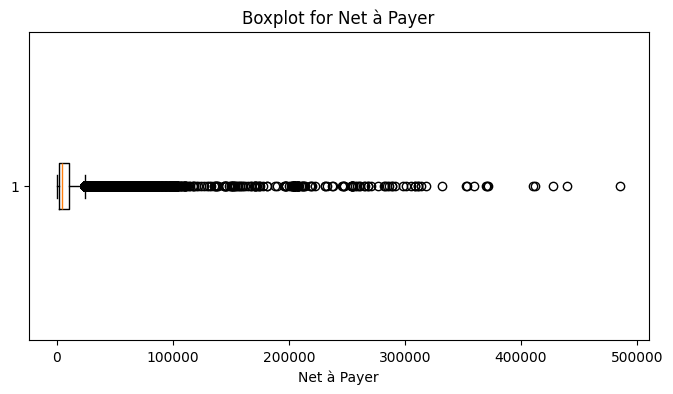

Règlement - Outliers: 5045
Règlement - Lower bound: -12016.0, Upper bound: 23760.0
Règlement - Percentage of outliers: 8.20%


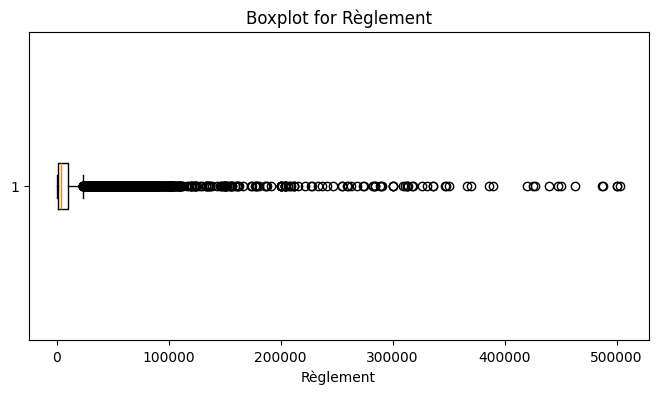

Reste à payer - Outliers: 26430
Reste à payer - Lower bound: 0.0, Upper bound: 0.0
Reste à payer - Percentage of outliers: 42.94%


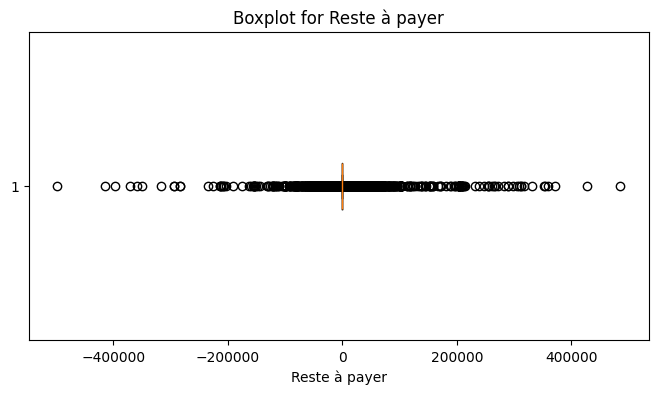

Solde global - Outliers: 6848
Solde global - Lower bound: -13905.800000000001, Upper bound: 34391.880000000005
Solde global - Percentage of outliers: 11.13%


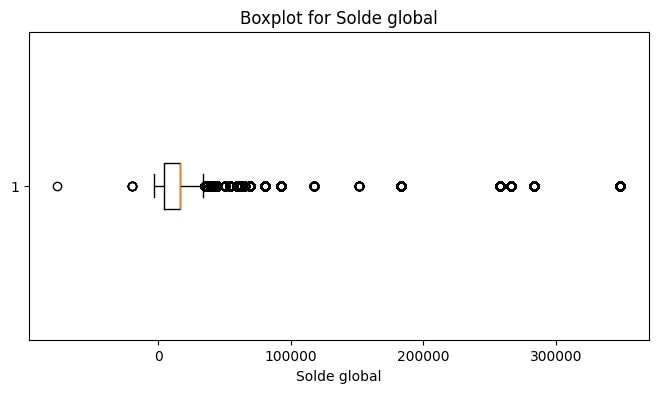

In [142]:
import numpy as np
import matplotlib.pyplot as plt

cols = ['Net à Payer', 'Règlement', 'Reste à payer', 'Solde global']

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} - Outliers: {outliers.shape[0]}")
    print(f"{col} - Lower bound: {lower}, Upper bound: {upper}")
    #percentage of outliers
    print(f"{col} - Percentage of outliers: {outliers.shape[0] / df.shape[0] * 100:.2f}%")

    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot for {col}')
    plt.xlabel(col)
    plt.show()

**Interpretation**

The IQR analysis shows a substantial number of outliers, especially for `Net ? Payer`. In this context, these extreme values should not be treated automatically as errors because they may correspond to high-value clients or unusually large invoices, which are strategically important for the business.


##  Validation Finale


In [143]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Année'].value_counts())
print(df['Code Client'].nunique())
print(df['Numéro de facture'].nunique())
print(df.head())


(61545, 13)
Date                 datetime64[ns]
Numéro de facture            object
Raison Sociale               object
Net à Payer                 float64
Règlement                   float64
Reste à payer               float64
Code Client                  object
Solde global                float64
year                          int32
invoice_id                   object
Année                         int32
Mois                          int32
Mois_Nom                     object
dtype: object
Date                 0
Numéro de facture    0
Raison Sociale       0
Net à Payer          0
Règlement            0
Reste à payer        0
Code Client          0
Solde global         0
year                 0
invoice_id           0
Année                0
Mois                 0
Mois_Nom             0
dtype: int64
Année
2025    31103
2024    30442
Name: count, dtype: int64
331
33841
            Date Numéro de facture Raison Sociale  Net à Payer  Règlement  \
19016 2024-07-27        G2498           AATEF M

**Interpretation**

The final validation confirms that the cleaned dataset contains 63,870 rows and 11 columns, with no remaining missing values in the retained variables. This indicates that the file is structurally ready for exploratory analysis and customer segmentation.


##  Save



In [144]:
import os
os.makedirs(r'C:/Users/H-Info/OneDrive/Desktop/facture2425 rfm model/data/processed', exist_ok=True)
df = df.sort_values(['Date', 'Numéro de facture']).reset_index(drop=True)
df.to_csv(r'C:/Users/H-Info/OneDrive/Desktop/facture2425 rfm model/data/processed/cleaned_data.csv', index=False, encoding='utf-8')
print("Cleaned file saved successfully.")


Cleaned file saved successfully.


**Interpretation**

The cleaned dataset was exported successfully to the processed-data folder. This export step is important because it creates a stable input for the EDA notebook, ensuring that the analytical phase starts from a documented and reproducible preprocessing stage.
